# Project future poses on OUR OWN dataset

This notebook does the same thing as `project_future_poses.ipynb`, but for **our own
recorded data** instead of RELLIS-3D: it draws the robot's future driving path onto every
camera image (**green ribbon** = ground the robot will drive over, **red line** = the exact
path of the robot's center) and saves the pictures to a new folder, `own_outputs/`.

**Our own dataset is not identical to RELLIS**, so a few things are handled carefully:

- **Image size is different.** RELLIS used a 1920×1200 camera; our recording uses a ZED
  camera at **640×360**. Instead of typing a fixed number, this notebook reads the real size
  from the first image.
- **The camera mount is different and its height above the ground is unknown.** RELLIS's robot
  (a Warthog) had its camera about 1 m up; ours is a smaller robot with the camera lower down.
  We do **not** know the exact number, so section 4 below lets us look at a few test frames and
  adjust the height until the green ribbon sits on the ground correctly.
- **The camera↔robot rotation direction is checked automatically**, the same safety check used
  in notebook 03, instead of assumed.



## 1. Settings — the only cell you normally need to change

In [37]:
from pathlib import Path

# ======== which recording to process ========
SEQUENCE = '00010'          # the only one we have so far; add more later the same way
# ==============================================
# seq 8 has some issue, need to check
# first 8 iamges of seq 9 are wrong ebcause the robot took long to move

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Own_dataset')
OUT_DIR   = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/own_outputs') / SEQUENCE
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_DIR = DATA_ROOT / SEQUENCE
IMG_DIR = SEQ_DIR / 'pylon_camera_node'      # the folder name is kept the same as RELLIS

# ---- how the future path is drawn -- these numbers describe OUR robot, not RELLIS's ----
FUTURE_STEPS    = 50     # how many future positions to project (a bit less if the path
                          # curves away quickly, e.g. a robot that turns a lot)
MIN_MOVE_M      = 0.10   # skip frames where the robot moved less than 10 cm
MIN_Z           = 0.5    # ignore path points closer than 0.5 m to the camera (or behind it)

# *** THESE TWO NEED TUNING -- we don't know the exact numbers for our robot yet ***
# Start with a guess, look at the preview in section 4, and adjust until the green
# ribbon sits on the ground under the robot's actual driving line.
GROUND_OFFSET_M = 0.35   # camera height above the ground, in meters (a Go2-sized robot
                          # is much lower than RELLIS's Warthog -- this is only a starting guess)
ROBOT_WIDTH_M   = 0.40   # width of the green ribbon, in meters (our robot is narrower
                          # than RELLIS's Warthog -- also only a starting guess)

assert IMG_DIR.is_dir(), f'folder not found: {IMG_DIR}'
print('sequence:', SEQUENCE)
print('output  :', OUT_DIR)

sequence: 00010
output  : s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\00010


## 2. Load the images, the poses, and the camera settings

In [38]:
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# ---- images and poses.txt (one pose line per image, in the same order) ----
image_paths = sorted(IMG_DIR.glob('*.jpg'))
pose_lines = [line for line in (SEQ_DIR / 'poses.txt').read_text().splitlines() if line.strip()]
print(f'{len(image_paths)} images, {len(pose_lines)} pose lines')
assert len(image_paths) == len(pose_lines), 'images and poses do not match -- check the data!'

# ---- read the real image size from the first picture, instead of assuming a fixed size ----
first_image = cv2.imread(str(image_paths[0]))
IMG_H, IMG_W = first_image.shape[:2]
print(f'image size: {IMG_W} x {IMG_H}')

def pose_line_to_matrix(line):
    """Turn one poses.txt line (12 numbers) into a 4x4 pose matrix of the robot in the world."""
    numbers = np.array(line.split(), dtype=np.float64)
    T = np.eye(4)
    T[:3, :4] = numbers.reshape(3, 4)
    return T

T_world_body = np.stack([pose_line_to_matrix(line) for line in pose_lines])

# ---- camera intrinsics: fx fy cx cy on one line, no distortion numbers in this export ----
fx, fy, cx, cy = np.loadtxt(SEQ_DIR / 'camera_info.txt').ravel()[:4]
K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
D = np.zeros(5)
print('camera K:', fx, fy, cx, cy)

1597 images, 1597 pose lines
image size: 640 x 360
camera K: 267.087921 267.087921 323.52774 187.650803


## 3. Camera↔robot rotation — checked automatically, not assumed

`poses.txt` tracks the **robot's body**, not the camera. `transforms.yaml` gives the fixed
rotation between the robot body and the camera, but not which *direction* it should be applied.
We try both directions and keep whichever one makes the future path land **in front of** the
camera (this is exactly the check used in notebook 03 for RELLIS).

In [39]:
yaml_data = yaml.safe_load((SEQ_DIR / 'transforms.yaml').read_text())
key = next(k for k in yaml_data if 'os1' in k and 'pylon' in k)   # kept for compatibility
q, t = yaml_data[key]['q'], yaml_data[key]['t']

T_yaml = np.eye(4)
T_yaml[:3, :3] = Rotation.from_quat([q['x'], q['y'], q['z'], q['w']]).as_matrix()
T_yaml[:3, 3] = [t['x'], t['y'], t['z']]

def fraction_in_front(T_world_camera, horizon=20, n_samples=30):
    """How often do FUTURE positions land in front of the camera (not behind it)?"""
    n = len(T_world_camera)
    sample_indices = np.linspace(0, max(1, n - horizon - 2), n_samples).astype(int)
    fractions = []
    for i in sample_indices:
        camera_from_world = np.linalg.inv(T_world_camera[i])
        future_positions = T_world_camera[i + 1:i + 1 + horizon, :3, 3]
        moved_enough = np.linalg.norm(future_positions - T_world_camera[i, :3, 3], axis=1) > 0.05
        if not moved_enough.any():
            continue
        points_in_camera = future_positions[moved_enough] @ camera_from_world[:3, :3].T + camera_from_world[:3, 3]
        fractions.append(float((points_in_camera[:, 2] > 0).mean()))
    return float(np.mean(fractions)) if fractions else 0.0

option_A = T_world_body @ np.linalg.inv(T_yaml)   # try the transform inverted
option_B = T_world_body @ T_yaml                   # try the transform as written

score_A = fraction_in_front(option_A)
score_B = fraction_in_front(option_B)
print(f'in-front score  A (inverted) = {score_A:.3f}   B (as written) = {score_B:.3f}')

if score_A >= score_B:
    T_world_cam = option_A
    print('using: inverted transform')
else:
    T_world_cam = option_B
    print('using: transform as written')

assert max(score_A, score_B) > 0.7, 'neither direction looks right -- check transforms.yaml'

in-front score  A (inverted) = 0.516   B (as written) = 1.000
using: transform as written


## 4. Drop frames where the robot barely moved (images and poses stay in step)

In [40]:
keep = [0]
for i in range(1, len(T_world_cam)):
    moved = np.linalg.norm(T_world_cam[i, :3, 3] - T_world_cam[keep[-1], :3, 3])
    if moved >= MIN_MOVE_M:
        keep.append(i)

images = [image_paths[i] for i in keep]
T_cam  = T_world_cam[keep]
T_body = T_world_body[keep]
print(f'kept {len(keep)} of {len(image_paths)} frames after the {MIN_MOVE_M} m filter')

kept 836 of 1597 frames after the 0.1 m filter


## 5. The projection functions (same math as notebook 03)

In [41]:
def future_ground_strip(idx):
    """Ground points of the future path: center line and left/right edges (world coordinates)."""
    center, left_edge, right_edge = [], [], []
    for j in range(idx + 1, min(idx + 1 + FUTURE_STEPS, len(T_body))):
        position = T_body[j][:3, 3]
        forward = T_body[j][:3, 0].copy()        # robot's forward direction
        forward[2] = 0.0
        length = np.linalg.norm(forward)
        if length < 1e-6:
            continue
        forward = forward / length
        left = np.array([-forward[1], forward[0], 0.0])
        ground = position - np.array([0.0, 0.0, GROUND_OFFSET_M])
        center.append(ground)
        left_edge.append(ground + 0.5 * ROBOT_WIDTH_M * left)
        right_edge.append(ground - 0.5 * ROBOT_WIDTH_M * left)
    return np.array(center), np.array(left_edge), np.array(right_edge)

def world_to_pixels(points_world, idx):
    """Project world points into the image of frame idx. Not-visible points come back as NaN."""
    if len(points_world) == 0:
        return np.zeros((0, 2)), np.zeros(0, bool)
    world_to_cam = np.linalg.inv(T_cam[idx])
    points_cam = points_world @ world_to_cam[:3, :3].T + world_to_cam[:3, 3]
    visible = points_cam[:, 2] > MIN_Z
    pixels = np.full((len(points_world), 2), np.nan)
    if visible.any():
        projected, _ = cv2.projectPoints(points_cam[visible].reshape(-1, 1, 3),
                                         np.zeros(3), np.zeros(3), K, D)
        pixels[visible] = projected.reshape(-1, 2)
    return pixels, visible

def path_mask_and_centerline(idx):
    """A full-size picture-shaped mask of the green ribbon, plus the red centerline points."""
    mask = np.zeros((IMG_H, IMG_W), np.uint8)
    center, left_edge, right_edge = future_ground_strip(idx)
    if len(center) < 2:
        return mask, np.zeros((0, 2))
    pixels_left,  visible_left  = world_to_pixels(left_edge, idx)
    pixels_right, visible_right = world_to_pixels(right_edge, idx)
    pixels_center, visible_center = world_to_pixels(center, idx)
    for j in range(len(center) - 1):
        if not (visible_left[j] and visible_right[j] and visible_left[j + 1] and visible_right[j + 1]):
            continue
        quad = np.array([pixels_left[j], pixels_left[j + 1], pixels_right[j + 1], pixels_right[j]])
        quad = np.clip(quad, -30000, 30000).astype(np.int32)
        if quad[:, 0].max() < 0 or quad[:, 0].min() >= IMG_W:
            continue
        if quad[:, 1].max() < 0 or quad[:, 1].min() >= IMG_H:
            continue
        cv2.fillPoly(mask, [quad], 1)
    return mask, pixels_center[visible_center]

def make_overlay(image_bgr, mask, centerline):
    """Draw the green ribbon and the red centerline on a copy of the image."""
    overlay = image_bgr.copy()
    ribbon = mask > 0
    overlay[ribbon] = (0.45 * overlay[ribbon] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    inside = centerline[np.all((centerline >= 0) & (centerline < [IMG_W, IMG_H]), axis=1)]
    if len(inside) >= 2:
        cv2.polylines(overlay, [inside.astype(np.int32)], False, (0, 0, 255), 3)
    return overlay

## 6. Tuning preview — **look at this before saving everything**

The green ribbon should hug the ground along the track the robot actually drove.

- Ribbon floats *above* the ground, up toward the horizon → **increase** `GROUND_OFFSET_M`.
- Ribbon sinks *below* the ground, too close to the camera → **decrease** `GROUND_OFFSET_M`.
- Ribbon looks too narrow or too wide for our robot → adjust `ROBOT_WIDTH_M`.

Change the numbers in section 1, then re-run from section 5 down to here, until it looks right.

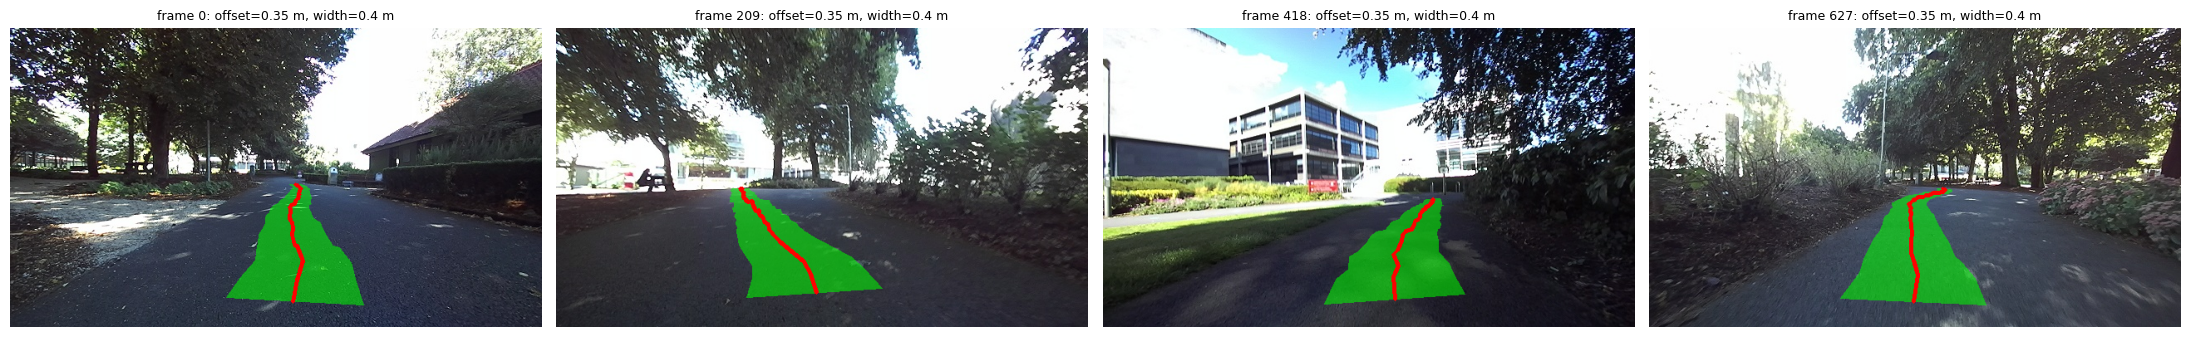

In [42]:
test_frames = [i for i in range(0, len(images), max(1, len(images) // 4)) if i < len(images)][:4]

fig, axes = plt.subplots(1, len(test_frames), figsize=(5.5 * len(test_frames), 5))
if len(test_frames) == 1:
    axes = [axes]
for ax, idx in zip(axes, test_frames):
    mask, centerline = path_mask_and_centerline(idx)
    image = cv2.imread(str(images[idx]))
    overlay = make_overlay(image, mask, centerline)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'frame {idx}: offset={GROUND_OFFSET_M} m, width={ROBOT_WIDTH_M} m', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Save the overlay for every frame that has a future path

Frames with no future path (end of the recording, or a sharp turn that sends the path
completely out of view) are skipped — only pictures **with** a path are saved.

In [43]:
import time
start_time = time.time()

n_saved = 0
n_skipped = 0
for i in range(len(images)):
    mask, centerline = path_mask_and_centerline(i)
    if mask.sum() == 0:                       # no future path in this picture -> skip it
        n_skipped += 1
        continue
    image = cv2.imread(str(images[i]))
    assert image is not None, f'could not read {images[i]}'
    overlay = make_overlay(image, mask, centerline)
    cv2.imwrite(str(OUT_DIR / images[i].name), overlay)
    n_saved += 1

print(f'finished in {time.time() - start_time:.0f} seconds')
print(f'saved   : {n_saved} pictures -> {OUT_DIR}')
print(f'skipped : {n_skipped} frames with no future path')

finished in 23 seconds
saved   : 832 pictures -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\00010
skipped : 4 frames with no future path


## 8. Look at a few of the saved pictures

832 pictures saved in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\00010


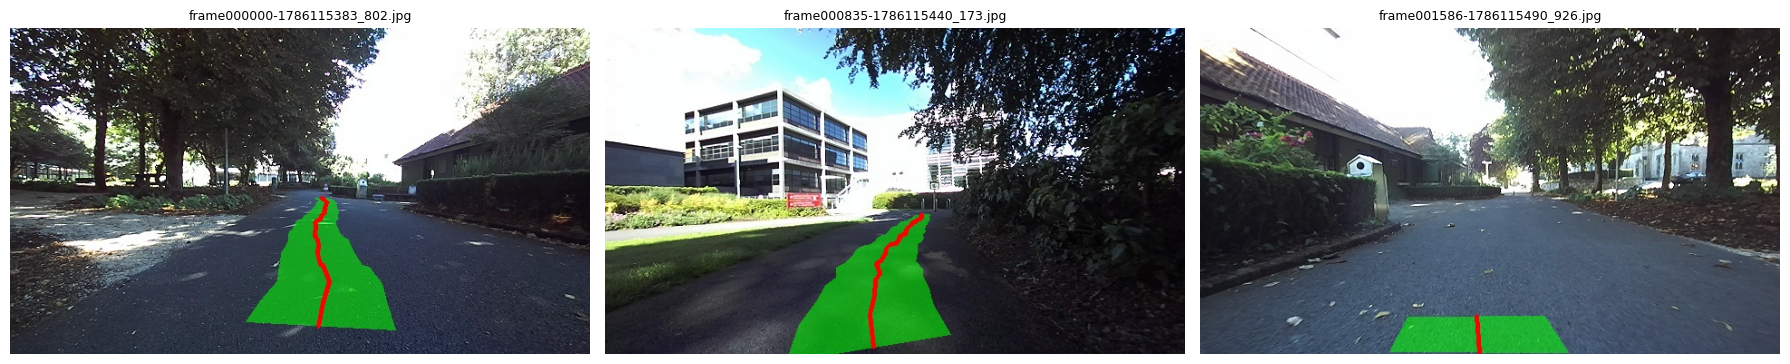

In [44]:
saved_files = sorted(OUT_DIR.glob('*.jpg'))
print(len(saved_files), 'pictures saved in', OUT_DIR)

if len(saved_files) > 0:
    samples = [saved_files[0], saved_files[len(saved_files) // 2], saved_files[-1]]
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 5))
    for ax, path in zip(axes, samples):
        picture = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        ax.imshow(picture)
        ax.set_title(path.name, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()